In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("../data/processed/cleaned.csv")

df.head()

df.columns

Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp',
       'hour', 'day', 'month', 'is_weekend'],
      dtype='str')

In [37]:
df["violation_type"].value_counts().head(20)

violation_type
["WRONG PARKING"]                                           112586
["NO PARKING"]                                              101768
["PARKING IN A MAIN ROAD","WRONG PARKING"]                    7851
["PARKING IN A MAIN ROAD","NO PARKING"]                       4031
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                    2538
["NO PARKING","PARKING IN A MAIN ROAD"]                       2071
["NO PARKING","DEFECTIVE NUMBER PLATE"]                       1929
["WRONG PARKING","PARKING IN A MAIN ROAD"]                    1608
["PARKING ON FOOTPATH","WRONG PARKING"]                        999
["PARKING IN A MAIN ROAD","WRONG PARKING","NO PARKING"]        749
["NO PARKING","WRONG PARKING"]                                 720
["WRONG PARKING","NO PARKING"]                                 661
["PARKING ON FOOTPATH","NO PARKING"]                           551
["NO PARKING","WRONG PARKING","PARKING IN A MAIN ROAD"]        482
["WRONG PARKING","PARKING ON FOOTPATH"]        

In [38]:
df["junction_name"].value_counts().head(20)

junction_name
No Junction                                   121814
BTP051 - Safina Plaza Junction                 12006
BTP082 - KR Market Junction                     9671
BTP040 - Elite Junction                         9385
BTP044 - Sagar Theatre Junction                 9056
BTP058 - Subbanna Junction                      4519
BTP211 - Central Street Junction                4170
BTP027 - Modi Bridge Junction                   3790
BTP057 - Anand Rao Junction                     3312
BTP020 - Hosahalli Metro Station                3136
BTP080 - NR Road, SP Road Junction              3024
BTP045 - Danvanthri Road Junction               2605
BTP001 - 10th Cross, Dr. Rajkumar Road          2464
BTP083 - AS Char Street, Mysore Road            2319
BTP032 - Windsor Circle                         2271
BTP016 - 5th Main Road, RPC Layout              1862
BTP042 - Minsk Square Junction (CTO)            1814
BTP038 - Mysore Bank Junction                   1659
BTP070 - Cholurpalya Junction, M

In [39]:
df["police_station"].value_counts().head(20)

police_station
Upparpet             29624
Shivajinagar         22300
Malleshwaram         18946
HAL Old Airport      16921
City Market          14636
Vijayanagara         11622
Kodigehalli           9185
Rajajinagar           9074
Magadi Road           6828
Jeevanbheemanagar     5821
K.R. Pura             5283
Halasuru Gate         5200
Mahadevapura          5156
Chikkajala            4789
High ground           4132
Bellandur             4004
HSR Layout            3876
Electronic City       3533
Byatarayanapura       3491
Halasur               3370
Name: count, dtype: int64

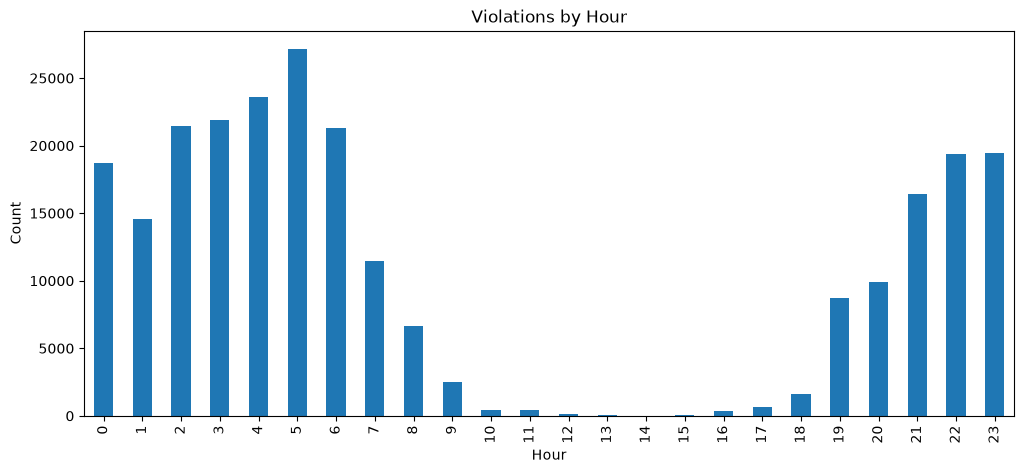

In [40]:
import matplotlib.pyplot as plt

hour_counts = (
    df["hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))
hour_counts.plot(kind="bar")
plt.title("Violations by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [41]:
(
    df["day"]
    .value_counts()
)

day
Sunday       38017
Tuesday      36177
Saturday     36174
Wednesday    35480
Thursday     34683
Friday       34412
Monday       31889
Name: count, dtype: int64

In [42]:
(
    df["month"]
    .value_counts()
)

month
March       52367
January     51626
February    47858
December    46926
November    33105
April       14950
Name: count, dtype: int64

In [43]:
no_junction_df = df[
    df["junction_name"] == "No Junction"
]

print(len(no_junction_df))

121814


In [44]:
(
    no_junction_df["location"]
    .value_counts()
    .head(30)
)

location
Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)                                                     3473
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)         3119
MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)                                               2525
Bellary Road, Vinayaka Nagar, Hebbal, Bengaluru, Karnataka. Pin-560024 (India)                                                  2405
New Horizon College Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin-560103 (India)                  2076
80 Feet Ring Road, Orion, Brigade Gateway, Malleshwaram West, Bengaluru, Karnataka. Pin-560055 (India)                          1773
Sahakar Nagar Road, Fortuna Acacia, Byatarayanapura, Bengaluru, Karnataka. Pin-560092 (India)                                   1655
Sahakar Nagar Road, Fortune Acacia, Byatarayanapura, Bengalu

In [45]:
print(
    "Unique Locations:",
    df["location"].nunique()
)

Unique Locations: 10199


In [46]:
df["location"].value_counts().head(20)

location
Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)                                                3473
Kamaraj Road, Sri Nagamma Devi Circle, Sivanchetti Gardens, Bengaluru, Karnataka. Pin-560042 (India)                       3164
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)    3119
MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)                                          2525
Bellary Road, Vinayaka Nagar, Hebbal, Bengaluru, Karnataka. Pin-560024 (India)                                             2405
5th Main Road, Kempe Gowda Circle, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)                                  2260
Dispensary Road, Tasker Town, Shivaji Nagar, Bengaluru, Karnataka. Pin-560001 (India)                                      2118
New Horizon College Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin

In [47]:
sample_location = (
    df["location"]
    .value_counts()
    .index[0]
)

sample_location

'Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)'

In [48]:
df[
    df["location"] == sample_location
][["latitude","longitude"]].describe()

,latitude,longitude
count,3473.000000,3473.000000
mean,13.185738,77.680050
std,0.001976,0.000452
min,13.183233,77.679356
25%,13.184208,77.679754
50%,13.184946,77.679860
75%,13.186915,77.680366
max,13.194027,77.683719


In [49]:
df["violation_type"].value_counts().head(10)

violation_type
["WRONG PARKING"]                                          112586
["NO PARKING"]                                             101768
["PARKING IN A MAIN ROAD","WRONG PARKING"]                   7851
["PARKING IN A MAIN ROAD","NO PARKING"]                      4031
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                   2538
["NO PARKING","PARKING IN A MAIN ROAD"]                      2071
["NO PARKING","DEFECTIVE NUMBER PLATE"]                      1929
["WRONG PARKING","PARKING IN A MAIN ROAD"]                   1608
["PARKING ON FOOTPATH","WRONG PARKING"]                       999
["PARKING IN A MAIN ROAD","WRONG PARKING","NO PARKING"]       749
Name: count, dtype: int64

In [50]:
df["vehicle_type"].value_counts().head(10)

vehicle_type
SCOOTER           78248
CAR               76221
MOTOR CYCLE       33556
PASSENGER AUTO    29494
MAXI-CAB           9665
LGV                6689
GOODS AUTO         2365
MOPED              1822
PRIVATE BUS        1246
VAN                1214
Name: count, dtype: int64

In [51]:
df["junction_name"].value_counts().head(10)

junction_name
No Junction                         121814
BTP051 - Safina Plaza Junction       12006
BTP082 - KR Market Junction           9671
BTP040 - Elite Junction               9385
BTP044 - Sagar Theatre Junction       9056
BTP058 - Subbanna Junction            4519
BTP211 - Central Street Junction      4170
BTP027 - Modi Bridge Junction         3790
BTP057 - Anand Rao Junction           3312
BTP020 - Hosahalli Metro Station      3136
Name: count, dtype: int64

In [52]:
df["location"].value_counts().head(20)

location
Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)                                                3473
Kamaraj Road, Sri Nagamma Devi Circle, Sivanchetti Gardens, Bengaluru, Karnataka. Pin-560042 (India)                       3164
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)    3119
MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)                                          2525
Bellary Road, Vinayaka Nagar, Hebbal, Bengaluru, Karnataka. Pin-560024 (India)                                             2405
5th Main Road, Kempe Gowda Circle, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)                                  2260
Dispensary Road, Tasker Town, Shivaji Nagar, Bengaluru, Karnataka. Pin-560001 (India)                                      2118
New Horizon College Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin

In [53]:
df[df["junction_name"]=="No Junction"]["location"].value_counts().head(20)

location
Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)                                                     3473
New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)         3119
MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)                                               2525
Bellary Road, Vinayaka Nagar, Hebbal, Bengaluru, Karnataka. Pin-560024 (India)                                                  2405
New Horizon College Road, Embassy Tech Village, Devara Beesana Halli, Bengaluru, Karnataka. Pin-560103 (India)                  2076
80 Feet Ring Road, Orion, Brigade Gateway, Malleshwaram West, Bengaluru, Karnataka. Pin-560055 (India)                          1773
Sahakar Nagar Road, Fortuna Acacia, Byatarayanapura, Bengaluru, Karnataka. Pin-560092 (India)                                   1655
Sahakar Nagar Road, Fortune Acacia, Byatarayanapura, Bengalu

In [54]:
hour_counts = (
    df["hour"]
    .value_counts()
    .sort_index()
)

print(hour_counts)

hour
0     18697
1     14603
2     21418
3     21896
4     23580
5     27140
6     21317
7     11480
8      6627
9      2513
10      408
11      411
12      144
13       31
14       14
15       51
16      378
17      625
18     1649
19     8691
20     9907
21    16390
22    19412
23    19450
Name: count, dtype: int64


In [55]:
df["hour"].describe()

count    246832.000000
mean          9.224748
std           8.362543
min           0.000000
25%           3.000000
50%           5.000000
75%          20.000000
max          23.000000
Name: hour, dtype: float64

In [56]:
hotspot_df = pd.read_csv("../data/processed/hotspot_scores.csv")

hotspot_df.head()

hotspot_df.sort_values(
    "violations",
    ascending=False
).head(20)

,hotspot_name,hotspot_type,violations,avg_severity,avg_vehicle_impact,recurrence_days,latitude,longitude
2927,BTP051 - Safina Plaza Junction,JUNCTION,12006,1.656588,1.803015,151,12.981220,77.608676
2949,BTP082 - KR Market Junction,JUNCTION,9671,1.932996,1.755661,152,12.964438,77.577222
2919,BTP040 - Elite Junction,JUNCTION,9385,1.480021,1.682152,152,12.976619,77.576607
2923,BTP044 - Sagar Theatre Junction,JUNCTION,9056,1.589554,1.977584,152,12.974972,77.578895
2932,BTP058 - Subbanna Junction,JUNCTION,4519,1.402301,2.552335,150,12.978989,77.578667
3047,BTP211 - Central Street Junction,JUNCTION,4170,1.787050,2.008393,148,12.983323,77.603464
2909,BTP027 - Modi Bridge Junction,JUNCTION,3790,1.756992,1.467018,146,12.998891,77.549413
6683,UNNAMED ROAD BEGUR CHIKKANAHALLI BENGALURU KAR...,ROAD_SEGMENT,3473,2.081486,2.670602,147,13.185738,77.680050
2931,BTP057 - Anand Rao Junction,JUNCTION,3312,1.887379,2.414553,148,12.979392,77.574405
2903,BTP020 - Hosahalli Metro Station,JUNCTION,3136,1.603635,1.125319,121,12.974214,77.545298


In [57]:
ranked_df = pd.read_csv(
    "../data/processed/ranked_zones.csv"
)

# ranked_df.head(20)

In [58]:
ranked_df[
    [
        "rank",
        "hotspot_name",
        "risk_score",
        "priority",
        "violations"
    ]
].head(20)

,rank,hotspot_name,risk_score,priority,violations
0,1,BTP051 - Safina Plaza Junction,87.883515,CRITICAL,12006
1,2,BTP082 - KR Market Junction,85.364913,CRITICAL,9671
2,3,BTP044 - Sagar Theatre Junction,83.896429,CRITICAL,9056
3,4,BTP040 - Elite Junction,83.676049,CRITICAL,9385
4,5,BTP058 - Subbanna Junction,74.093587,CRITICAL,4519
5,6,BTP211 - Central Street Junction,72.947812,CRITICAL,4170
6,7,UNNAMED ROAD BEGUR CHIKKANAHALLI BENGALURU KAR...,72.023898,CRITICAL,3473
7,8,BTP027 - Modi Bridge Junction,70.546884,CRITICAL,3790
8,9,BTP057 - Anand Rao Junction,70.470204,CRITICAL,3312
9,10,"BTP080 - NR Road, SP Road Junction",67.695228,CRITICAL,3024
